<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3652684/522354871.py:11: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(path, sep='\s', comment="#", names=["Coordinate", "Energy"])
/tmp/ipykernel_3652684/522354871.py:11: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(path, sep='\s', comment="#", names=["Coordinate", "Energy"])


Minimum bond length: 1.1233 Å


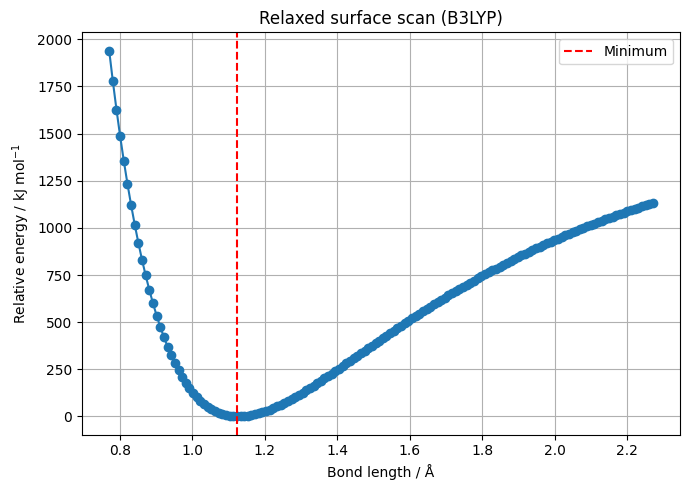

,Coordinate,Energy,Energy_kJmol
0,2.271000,-112.862598,1132.628616
1,2.260933,-112.864968,1126.404974
2,2.250866,-112.867376,1120.083664
3,2.240799,-112.869809,1113.696690
4,2.230732,-112.872271,1107.231581


In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to your ORCA relaxed scan file
path = "/media/storage_6/cte/pr_bachelor/scan/co/b3lyp_6_311_g_dp/co.relaxscanscf.dat"

# Method used (manually set or parse from filename)
method = "B3LYP"  # e.g., HF, B3LYP, MP2

# Read the file, skipping header lines that start with '#'
df = pd.read_csv(path, sep='\s', comment="#", names=["Coordinate", "Energy"])

# Convert energy from Hartree to kJ/mol (optional)
HARTREE_TO_KJMOL = 2625.49962
df["Energy_kJmol"] = (df["Energy"] - df["Energy"].min()) * HARTREE_TO_KJMOL

# Find minimum point
min_idx = df["Energy_kJmol"].idxmin()
min_coord = df.loc[min_idx, "Coordinate"]
min_energy = df.loc[min_idx, "Energy_kJmol"]

# Print minimum
print(f"Minimum bond length: {min_coord:.4f} Å")

# Plot
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(df["Coordinate"], df["Energy_kJmol"], marker="o", markersize=6, linestyle="-")
ax.axvline(min_coord, color="red", linestyle="--", label="Minimum")
ax.set_xlabel("Bond length / Å")
ax.set_ylabel("Relative energy / kJ mol$^{-1}$")
ax.set_title(f"Relaxed surface scan ({method})")
ax.legend()
ax.grid(True)
fig.tight_layout()

# Save figure
fig.savefig(f"relaxed_surface_scan_{method}.png", dpi=300)
plt.show()

# Display table of data
df.head()


<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3652684/3446212318.py:34: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file, sep='\s+', comment="#", names=["Coordinate", "Energy"])


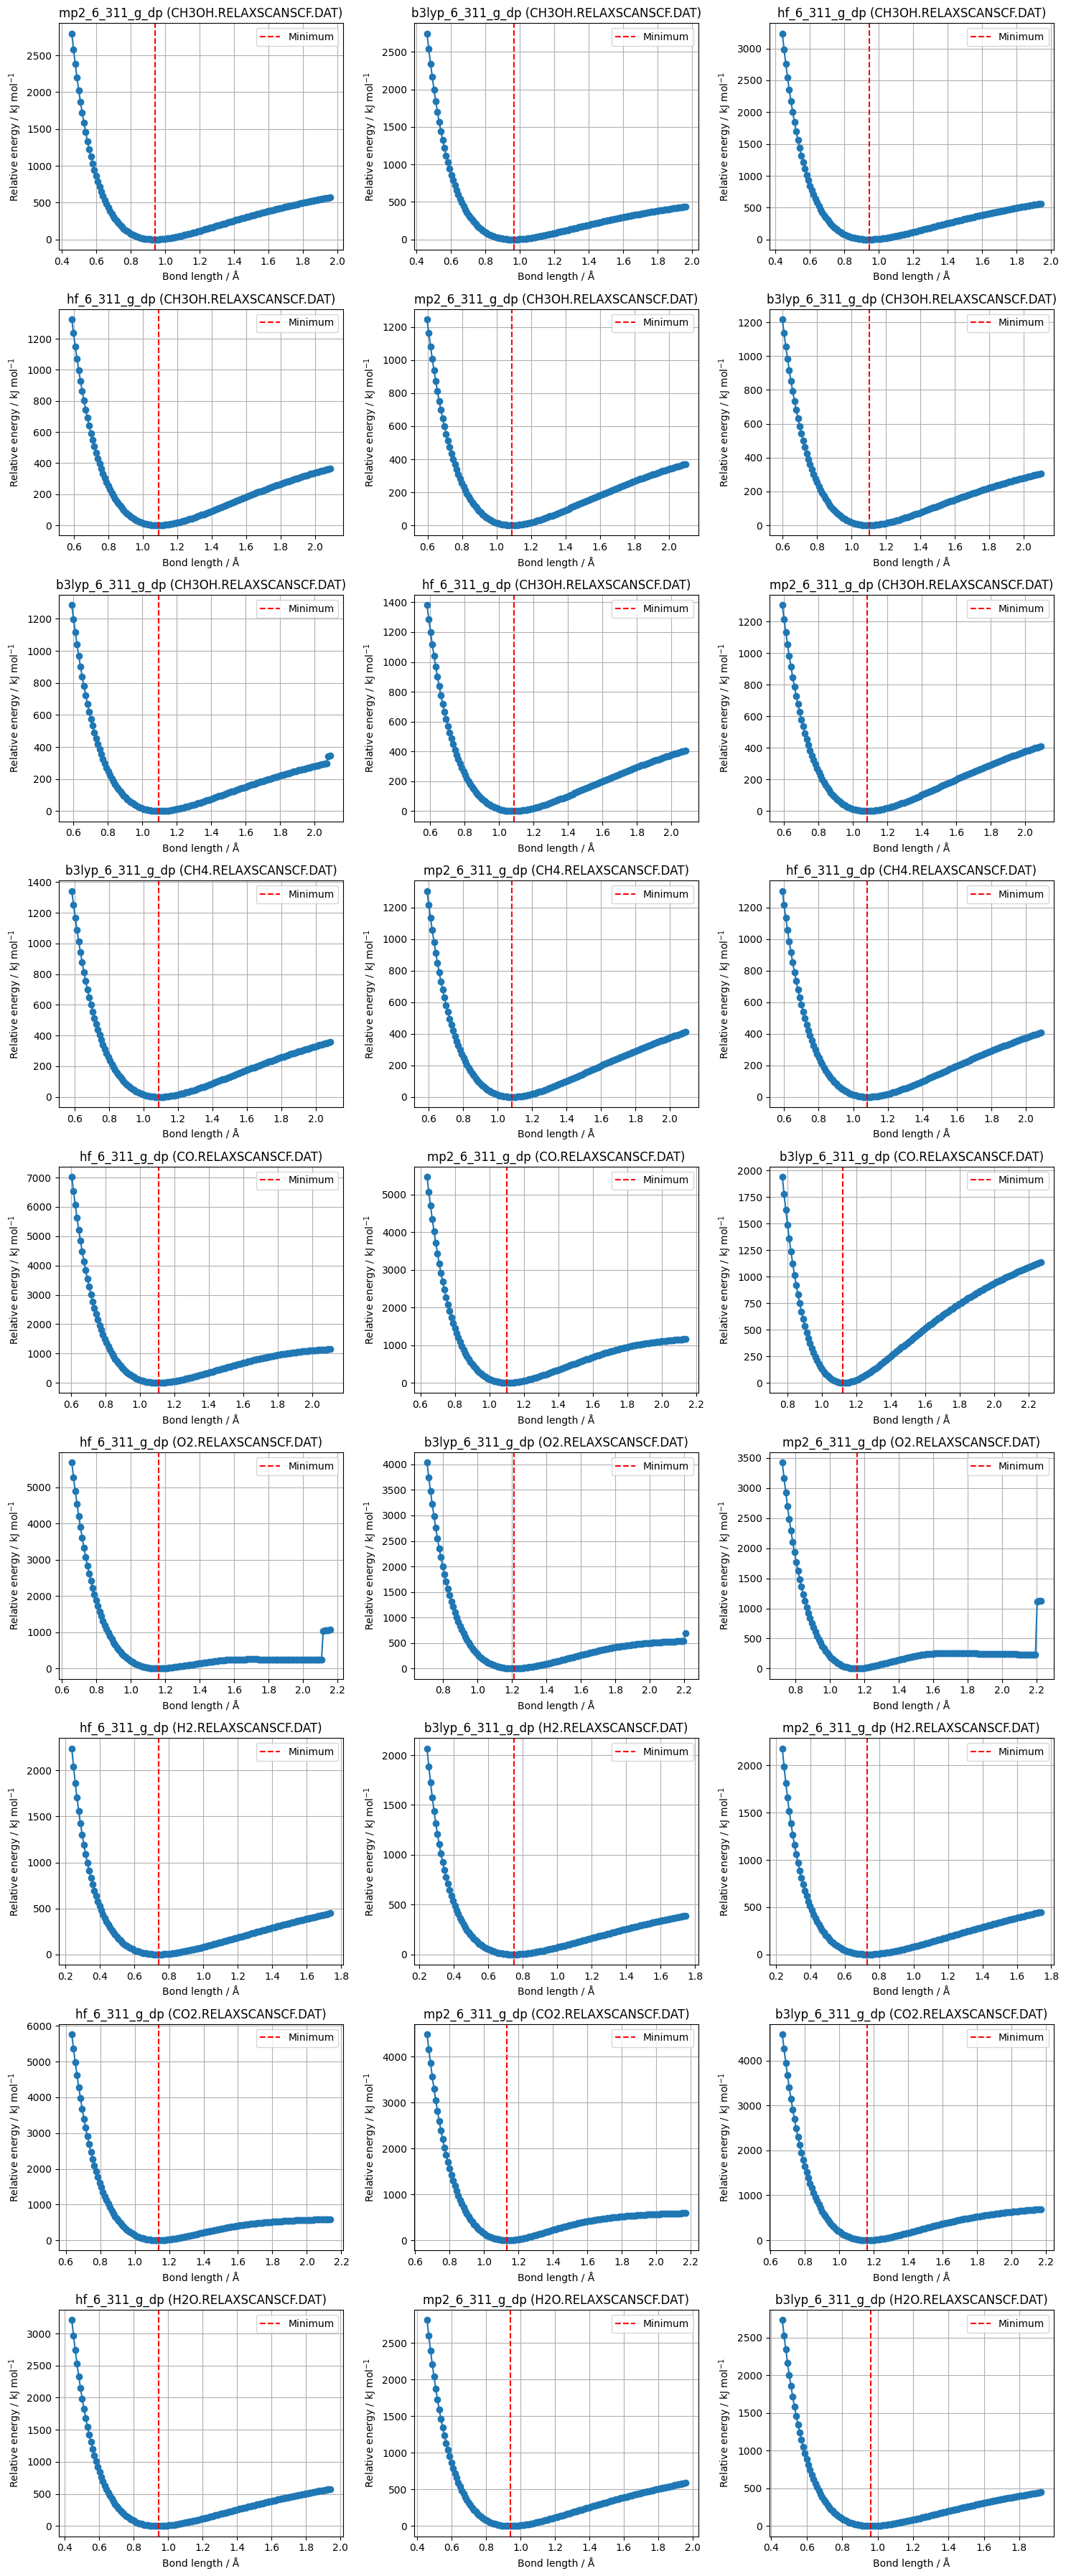

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Main directory
root_dir = "/media/storage_6/cte/pr_bachelor/scan"

# Conversion factor Hartree -> kJ/mol
HARTREE_TO_KJMOL = 2625.49962

# Find all relaxed scan files recursively
scan_files = []
for dirpath, _, filenames in os.walk(root_dir):
    for filename in filenames:
        if filename.endswith(".relaxscanscf.dat"):
            scan_files.append(os.path.join(dirpath, filename))

# Determine grid size
n_files = len(scan_files)
n_cols = 3  # number of columns in the grid
n_rows = (n_files + n_cols - 1) // n_cols

# Create figure and axes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for ax, file in zip(axes, scan_files):
    # Extract molecule and method from folder/filename
    parts = file.split(os.sep)
    molecule = parts[-2]  # assuming molecule folder is parent of file
    method = os.path.basename(file).split("_")[0].upper()  # e.g., B3LYP, HF, MP2

    # Read data
    df = pd.read_csv(file, sep='\s+', comment="#", names=["Coordinate", "Energy"])
    df["Energy_kJmol"] = (df["Energy"] - df["Energy"].min()) * HARTREE_TO_KJMOL

    # Find minimum
    min_idx = df["Energy_kJmol"].idxmin()
    min_coord = df.loc[min_idx, "Coordinate"]

    # Plot
    ax.plot(df["Coordinate"], df["Energy_kJmol"], marker="o", linestyle="-")
    ax.axvline(min_coord, color="red", linestyle="--", label="Minimum")
    ax.set_title(f"{molecule} ({method})")
    ax.set_xlabel("Bond length / Å")
    ax.set_ylabel("Relative energy / kJ mol$^{-1}$")
    ax.legend()
    ax.grid(True)

# Hide any unused axes
for ax in axes[n_files:]:
    ax.axis("off")

plt.tight_layout()
#plt.savefig("all_relaxed_surface_scans_grid.png", dpi=300)
plt.show()


### Calculation Times of the Surface scans

In [56]:
import os
import re
import pandas as pd
from IPython.display import display

# Function to extract runtime from an ORCA .out file
def extract_runtime(file_path):
    runtime_pattern = re.compile(
        r"TOTAL RUN TIME:\s+(\d+) days\s+(\d+) hours\s+(\d+) minutes\s+(\d+) seconds(?:\s+(\d+)\s+msec)?"
    )
    try:
        with open(file_path, "r", errors="ignore") as f:
            for line in f:
                match = runtime_pattern.search(line)
                if match:
                    _, hours, minutes, seconds, msec = match.groups()
                    hours, minutes, seconds = map(int, [hours, minutes, seconds])
                    msec = int(msec) if msec else 0

                    total_seconds = hours*3600 + minutes*60 + seconds + msec/1000

                    return {
                        "Hours": hours,
                        "Minutes": minutes,
                        "Seconds": seconds,
                        "Milliseconds": msec,
                        "Runtime (s)": total_seconds
                    }
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
    return None

# Main scan function
def scan_orca_outputs(root_dir):
    data = []
    for dirpath, _, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith(".out"):
                filepath = os.path.join(dirpath, filename)
                runtime_info = extract_runtime(filepath)
                if runtime_info is not None:
                    parts = filepath.split(os.sep)
                    
                    # Extract method from parent folder, molecule from filename
                    method = parts[-2]      # e.g. mp2_6_311_g_dp
                    molecule = os.path.splitext(filename)[0]  # filename without .out
                    
                    # Last 3 parts of the directory path
                    directory_last3 = os.path.join(*parts[-4:-1])
                    
                    entry = {
                        "Molecule": molecule,
                        "Method": method,
                        "Directory": directory_last3
                    }
                    entry.update(runtime_info)
                    data.append(entry)
    return pd.DataFrame(data)

# Set your root directory here
root_directory = "/media/storage_6/cte/pr_bachelor/scan"
runtimes_df = scan_orca_outputs(root_directory)

# Display nicely
display(runtimes_df)

# Print summary
print("Total files found:", len(runtimes_df))
print("Total runtime (s):", runtimes_df["Runtime (s)"].sum())
print("Total runtime (h):", runtimes_df["Runtime (s)"].sum() / 3600)
print("Total runtime (days):", runtimes_df["Runtime (s)"].sum() / 86400)


,Molecule,Method,Directory,Hours,Minutes,Seconds,Milliseconds,Runtime (s)
0,ch3oh,mp2_6_311_g_dp,ch3oh/oh/mp2_6_311_g_dp,0,48,10,145,2890.145
1,ch3oh,b3lyp_6_311_g_dp,ch3oh/oh/b3lyp_6_311_g_dp,0,28,0,823,1680.823
2,ch3oh,hf_6_311_g_dp,ch3oh/oh/hf_6_311_g_dp,0,10,45,667,645.667
3,ch3oh,hf_6_311_g_dp,ch3oh/ch_2/hf_6_311_g_dp,0,15,50,471,950.471
4,ch3oh,mp2_6_311_g_dp,ch3oh/ch_2/mp2_6_311_g_dp,1,5,36,764,3936.764
5,ch3oh,b3lyp_6_311_g_dp,ch3oh/ch_2/b3lyp_6_311_g_dp,0,43,55,684,2635.684
6,ch3oh,b3lyp_6_311_g_dp,ch3oh/ch/b3lyp_6_311_g_dp,0,48,26,367,2906.367
7,ch3oh,hf_6_311_g_dp,ch3oh/ch/hf_6_311_g_dp,0,15,17,530,917.530
8,ch3oh,mp2_6_311_g_dp,ch3oh/ch/mp2_6_311_g_dp,0,57,48,389,3468.389
9,ch4,b3lyp_6_311_g_dp,scan/ch4/b3lyp_6_311_g_dp,0,27,9,499,1629.499


Total files found: 27
Total runtime (s): 47882.171
Total runtime (h): 13.300603055555555
Total runtime (days): 0.5541917939814816


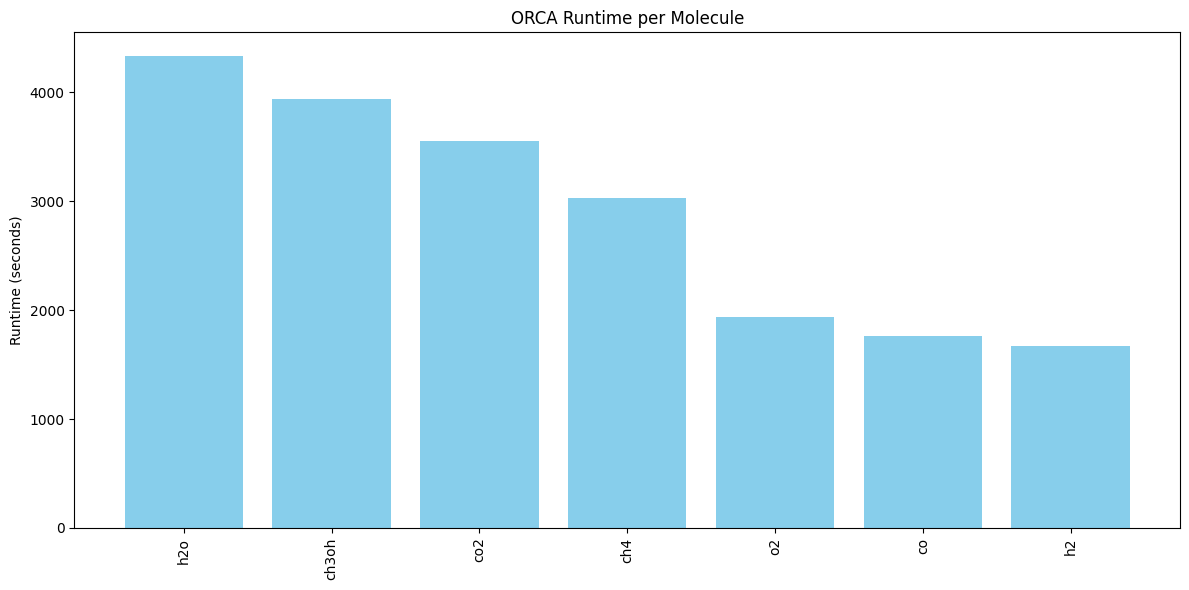

In [57]:
import matplotlib.pyplot as plt

# Sort DataFrame by runtime for better visualization
runtimes_df_sorted = runtimes_df.sort_values(by="Runtime (s)", ascending=False)

# Create bar chart
plt.figure(figsize=(12, 6))
plt.bar(runtimes_df_sorted["Molecule"], runtimes_df_sorted["Runtime (s)"], color='skyblue')
plt.xticks(rotation=90)  # Rotate molecule names for readability
plt.ylabel("Runtime (seconds)")
plt.title("ORCA Runtime per Molecule")
plt.tight_layout()
plt.show()


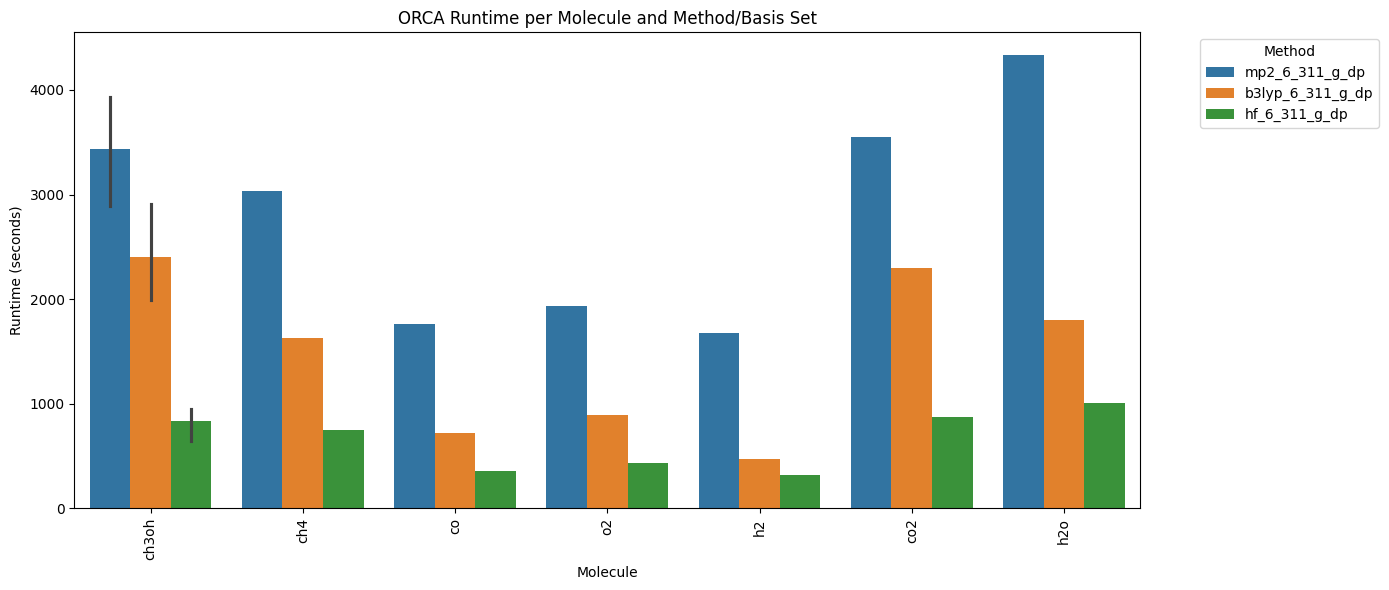

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure
plt.figure(figsize=(14, 6))

# Grouped bar chart: Molecule on x-axis, Runtime on y-axis, colored by Method
sns.barplot(
    data=runtimes_df,
    x="Molecule",
    y="Runtime (s)",
    hue="Method"
)

plt.xticks(rotation=90)  # Rotate x-axis labels
plt.ylabel("Runtime (seconds)")
plt.title("ORCA Runtime per Molecule and Method/Basis Set")
plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside
plt.tight_layout()
plt.show()


### Checking Output Files